<a href="https://colab.research.google.com/github/Yovana-Palencia/Mineria-De-Datos/blob/main/Tercer_parcial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Tercer parcial

In [1]:
import math

# Datos de entrenamiento
X = [(2,4), (4,4), (4,2), (6,2)]
y = ['Rojo', 'Rojo', 'Azul', 'Azul']

# Punto a clasificar
P = (3, 3)

In [2]:
def distancia_euclidiana(p1, p2):
    return math.sqrt((p1[0]-p2[0])**2 + (p1[1]-p2[1])**2)

In [3]:
distancias = []
for i in range(len(X)):
    d = distancia_euclidiana(P, X[i])
    distancias.append((d, y[i]))

# Ordenar por distancia
distancias.sort(key=lambda x: x[0])

print(distancias)
print("Clase asignada:", distancias[0][1])

[(1.4142135623730951, 'Rojo'), (1.4142135623730951, 'Rojo'), (1.4142135623730951, 'Azul'), (3.1622776601683795, 'Azul')]
Clase asignada: Rojo


In [4]:
from collections import Counter

k = 3
vecinos = distancias[:k]

clases = [clase for _, clase in vecinos]
resultado = Counter(clases).most_common(1)

print("Vecinos:", vecinos)
print("Clase asignada:", resultado[0][0])

Vecinos: [(1.4142135623730951, 'Rojo'), (1.4142135623730951, 'Rojo'), (1.4142135623730951, 'Azul')]
Clase asignada: Rojo


In [5]:
def distancia_manhattan(p1, p2):
    return abs(p1[0]-p2[0]) + abs(p1[1]-p2[1])

X = [(1,1), (2,3), (5,4), (6,5)]
y = ['Baja', 'Baja', 'Alta', 'Alta']
P = (4,3)

distancias = []

for i in range(len(X)):
    d = distancia_manhattan(P, X[i])
    distancias.append((d, y[i]))

distancias.sort(key=lambda x: x[0])

print(distancias)
print("Clase asignada:", distancias[0][1])

[(2, 'Baja'), (2, 'Alta'), (4, 'Alta'), (5, 'Baja')]
Clase asignada: Baja


In [6]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier

In [7]:
X = np.array([
[5.1, 3.5],
[4.9, 3.0],
[6.2, 3.4],
[6.0, 2.9]
])

y = np.array(['Setosa', 'Setosa', 'Versicolor', 'Versicolor'])

P = np.array([[5.8, 3.2]])

In [8]:
modelo = KNeighborsClassifier(n_neighbors=3)
modelo.fit(X, y)

prediccion = modelo.predict(P)
print("Clase predicha:", prediccion[0])

Clase predicha: Versicolor


🟥 Parte A: k‑NN SIN normalización

In [9]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier

# Dataset
X = np.array([
[25, 8000],
[30, 12000],
[45, 45000],
[50, 60000],
[35, 15000],
[48, 55000]
])

y = np.array(['Alto', 'Alto', 'Bajo', 'Bajo', 'Alto', 'Bajo'])

nuevo_cliente = np.array([[40, 20000]])

# Modelo k-NN
modelo = KNeighborsClassifier(n_neighbors=3)
modelo.fit(X, y)

# Predicción
modelo.predict(nuevo_cliente)

array(['Alto'], dtype='<U4')

🟢 Parte B: k‑NN CON normalización

In [10]:
from sklearn.preprocessing import StandardScaler

# Escalamiento
scaler = StandardScaler()#instanciamos
X_norm = scaler.fit_transform(X)#A la matriz de características se le aplica la transformación
nuevo_norm = scaler.transform(nuevo_cliente)

# Modelo k-NN
modelo_norm = KNeighborsClassifier(n_neighbors=3)
modelo_norm.fit(X_norm, y)

# Predicción
modelo_norm.predict(nuevo_norm)

array(['Alto'], dtype='<U4')

In [11]:
X_norm #Esto ayuda a evitar los sesgos, conservando la variación

array([[-1.47069757, -1.14533092],
       [-0.93912013, -0.95833812],
       [ 0.65561217,  0.58435251],
       [ 1.1871896 ,  1.28557552],
       [-0.4075427 , -0.81809351],
       [ 0.97455863,  1.05183452]])

Ejercicio de K-NN

In [12]:
#Utiliza el dataset de las flores Iris.

import seaborn as sns
iris = sns.load_dataset('iris')
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


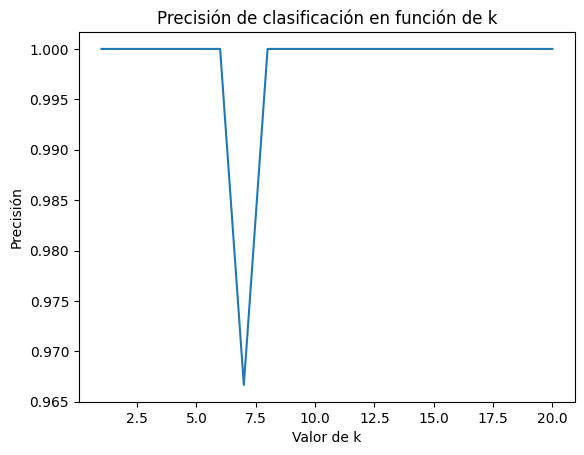

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
#Realiza una separación de conjunto de datos de entrenamiento y el de prueba, de la siguiente manera:

#Entrenamiento 80%
#Prueba 20%
#Evalua la clasificación utilizando K-NN
X = iris.drop('species', axis=1)
y = iris['species']

#Entrenamiento 80%
#Prueba 20%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#Evalua la clasificación utilizando K-NN
k_values = range(1, 21)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

#Investiga que es el codo
    y_pred = knn.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    accuracies.append(accuracy)
#Y determina el valor de k adecuaduado para clasificar las flores Iris
plt.plot(k_values, accuracies)
plt.xlabel('Valor de k')
plt.ylabel('Precisión')
plt.title('Precisión de clasificación en función de k')
plt.show()

In-Depth: Decision Trees and Random Forests

In [14]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()

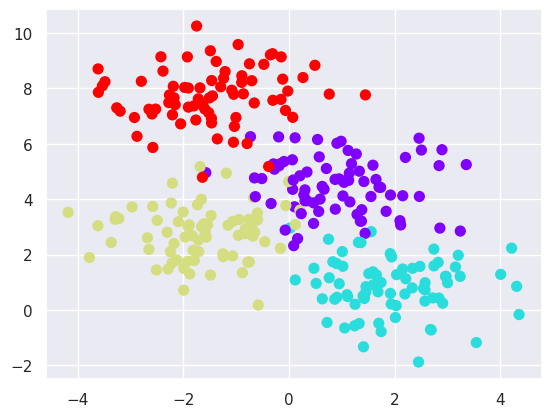

In [15]:
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=300, centers=4,
                  random_state=0, cluster_std=1.0)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='rainbow');